# Extended Data Figure 14

In [29]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

In [30]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


In [31]:
# load library

LIB = pd.read_csv(BASE + 'MBESv2_CORRECTED.csv')
LIB_FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')

ABE = LIB[LIB['Editor'] == 'ABE'].reset_index(drop=True)
ABE_FOCUSED = LIB_FOCUSED[LIB_FOCUSED['Editor'] == 'ABE'].reset_index(drop=True)

## 14a

Scatter plots showing the correlation of guide-level median LFC z-scores between the focused ABE screens using v1 and v2 baselines, across three tissue contexts (D15 in vitro, Spleen, and Bone Marrow). Only guides with target base editing ≥ 10% and FDR ≤ 0.1 in at least one screen are shown. Blue dots, targeting guides; red dots, control guides. $R_P$, Pearson correlation coefficient; $R_S$, Spearman correlation coefficient.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


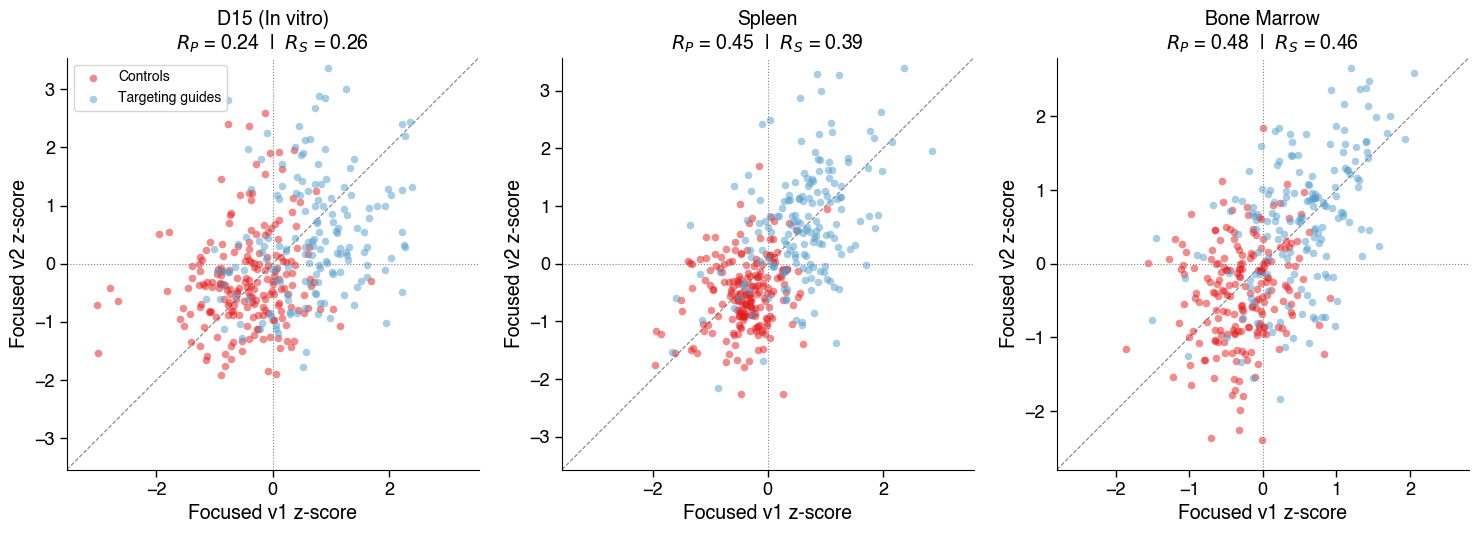

In [32]:
from scipy.stats import pearsonr, spearmanr

ABE_T0  = dfs['ABE_EPO_T0']
ABE_FSR = dfs['ABE_EPO_T0_FSR']

min_edit           = 10
FDR_cutoff         = 0.1
min_sensor_focused = 100

cond_list   = ['d15', 'spleen', 'bm']
cond_labels = {'d15': 'D15 (In vitro)', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cond in zip(axes, cond_list):
    z_col      = f'z_score_median_{cond}'
    fdr_col    = f'FDR_{cond}_fishers'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    t0_targ = ABE_T0[ABE_T0['classification'] == 'targeting guide'].copy()
    if sensor_col in t0_targ.columns:
        t0_targ = t0_targ[t0_targ[sensor_col] >= min_sensor_focused]
    t0_targ = t0_targ[t0_targ[edit_col] >= min_edit][['gRNA_id', z_col, fdr_col]].rename(
        columns={z_col: 'z_t0', fdr_col: 'fdr_t0'})

    fsr_targ = ABE_FSR[ABE_FSR['classification'] == 'targeting guide'].copy()
    if sensor_col in fsr_targ.columns:
        fsr_targ = fsr_targ[fsr_targ[sensor_col] >= min_sensor_focused]
    fsr_targ = fsr_targ[fsr_targ[edit_col] >= min_edit][['gRNA_id', z_col, fdr_col]].rename(
        columns={z_col: 'z_fsr', fdr_col: 'fdr_fsr'})

    merged = pd.merge(t0_targ, fsr_targ, on='gRNA_id').dropna(subset=['z_t0', 'z_fsr'])

    t0_ctrl  = ABE_T0[ ABE_T0['classification'].isin(['non-targeting control','safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col:'z_t0'})
    fsr_ctrl = ABE_FSR[ABE_FSR['classification'].isin(['non-targeting control','safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col:'z_fsr'})
    ctrl     = pd.merge(t0_ctrl, fsr_ctrl, on='gRNA_id').dropna()

    r_p, _ = pearsonr( merged['z_t0'], merged['z_fsr'])
    r_s, _ = spearmanr(merged['z_t0'], merged['z_fsr'])

    ax.scatter(ctrl['z_t0'],   ctrl['z_fsr'],   c='#e41a1c', s=30, alpha=0.5, linewidths=0, label='Controls')
    ax.scatter(merged['z_t0'], merged['z_fsr'], c=blues[3],  s=30, alpha=0.5, linewidths=0, label='Targeting guides')

    lim = max(abs(merged['z_t0']).max(), abs(merged['z_fsr']).max()) * 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.plot([-lim, lim], [-lim, lim], color='grey', linestyle='--', linewidth=0.8, zorder=0)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')

    ax.set_xlabel('Focused v1 z-score', fontsize=14)
    ax.set_ylabel('Focused v2 z-score', fontsize=14)
    ax.set_title(
        f"{cond_labels[cond]}\n"
        f"$R_P$ = {r_p:.2f}  |  $R_S$ = {r_s:.2f}",
        fontsize=14)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13, direction='out', length=5, width=1)
    if cond == 'd15':
        ax.legend(fontsize=10)

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-14/14a.pdf', bbox_inches='tight', dpi=300)
plt.show()


## 14b

Venn diagrams showing the overlap of hits between the focused ABE screens using v1 and v2 baselines, across three tissue contexts (Day 15 In Vitro, Spleen, and Bone Marrow). Hits are defined as guides with FDR ≤ 0.1 and |LFC| ≥ 1.0.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


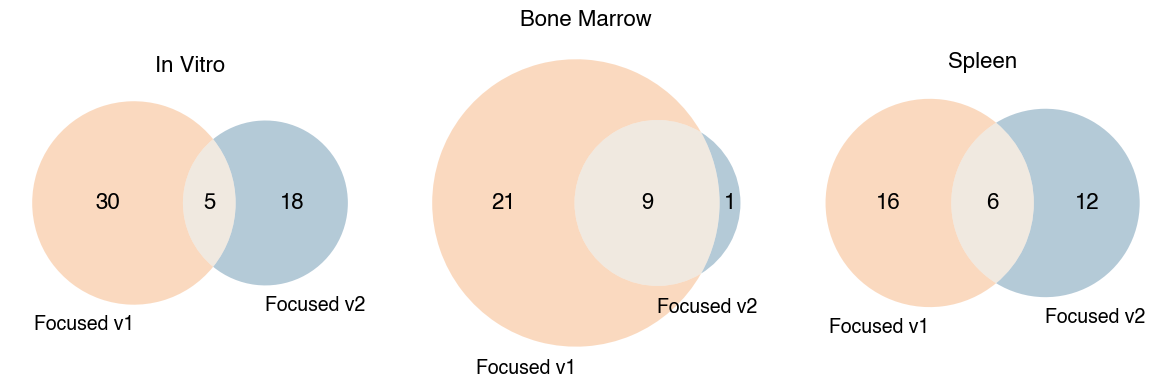

In [33]:
from matplotlib_venn import venn2

min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_focused = 100

ABE_T0  = dfs['ABE_EPO_T0']
ABE_FSR = dfs['ABE_EPO_T0_FSR']

cond_list   = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cond in zip(axes, cond_list):
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    t0_targ = ABE_T0[ABE_T0['classification'] == 'targeting guide'].copy()
    if sensor_col in t0_targ.columns:
        t0_targ = t0_targ[t0_targ[sensor_col] >= min_sensor_focused]
    t0_targ = t0_targ[t0_targ[edit_col] >= min_edit][['gRNA_id', fdr_col, lfc_col]]

    fsr_targ = ABE_FSR[ABE_FSR['classification'] == 'targeting guide'].copy()
    if sensor_col in fsr_targ.columns:
        fsr_targ = fsr_targ[fsr_targ[sensor_col] >= min_sensor_focused]
    fsr_targ = fsr_targ[fsr_targ[edit_col] >= min_edit][['gRNA_id', fdr_col, lfc_col]]

    t0_hits  = set(t0_targ.loc[ (t0_targ[fdr_col]  <= FDR_cutoff) & (t0_targ[lfc_col].abs()  >= LFC_cutoff), 'gRNA_id'])
    fsr_hits = set(fsr_targ.loc[(fsr_targ[fdr_col] <= FDR_cutoff) & (fsr_targ[lfc_col].abs() >= LFC_cutoff), 'gRNA_id'])

    v = venn2([t0_hits, fsr_hits],
              set_labels=('Focused v1', 'Focused v2'),
              set_colors=('#f4a26188', '#457b9d88'),
              ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(14)
    for text in v.subset_labels:
        if text: text.set_fontsize(16)

    ax.set_title(cond_labels[cond], fontsize=16)

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-14/14b.pdf', bbox_inches='tight', dpi=300)
plt.show()


## 14c

Heatmaps visualizing the z-scores of the top 10 enrichers from the focused ABE screen (v1 baseline) in Day 15 in vitro, Spleen, and Bone Marrow, alongside their corresponding z-scores in the focused ABE screen (v2 baseline). Guides filtered to sensor reads ≥ 100, input median ≥ 2, base editing ≥ 10%, FDR ≤ 0.1, |LFC| ≥ 1.0.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


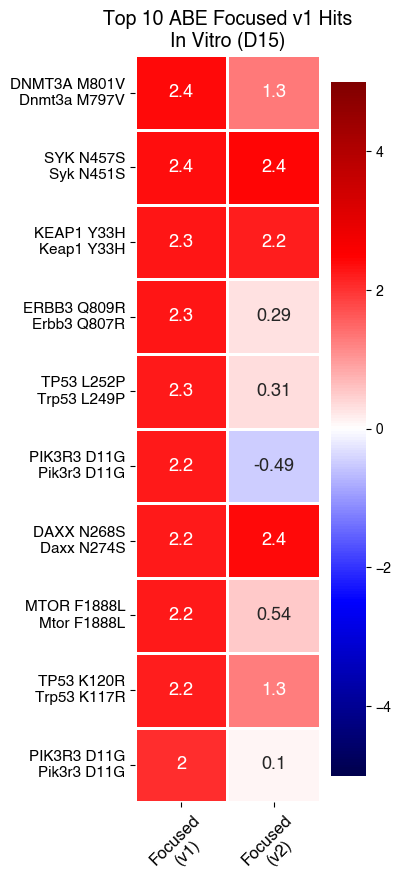

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


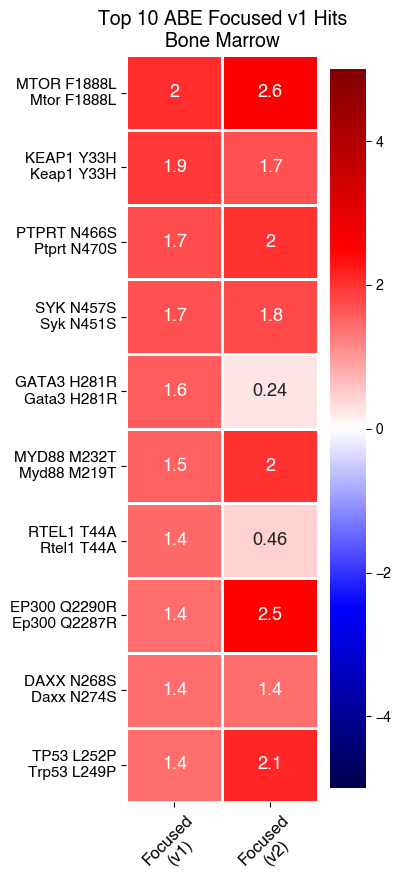

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


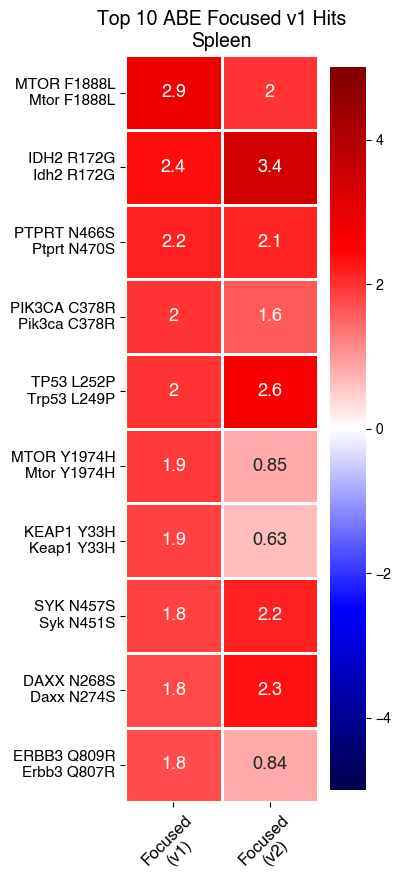

In [34]:
min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_focused = 100

ABE_T0  = dfs['ABE_EPO_T0']
ABE_FSR = dfs['ABE_EPO_T0_FSR']

cond_list   = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro (D15)', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    t0 = ABE_T0[ABE_T0['classification'] == 'targeting guide'].copy()
    if sensor_col in t0.columns:
        t0 = t0[t0[sensor_col] >= min_sensor_focused]
    t0 = t0[t0['Input_median'] >= 2]
    t0 = t0[
        (t0[edit_col]  >= min_edit) &
        (t0[fdr_col]   <= FDR_cutoff) &
        (t0[lfc_col].abs() >= LFC_cutoff)
    ].copy()
    t0 = t0.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = t0.iloc[:10].copy()

    fsr = ABE_FSR[['gRNA_id', z_col]].rename(columns={z_col: 'z_fsr'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], fsr, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_t0'})

    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_t0', 'z_fsr']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['Focused\n(v1)', 'Focused\n(v2)'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE Focused v1 Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figures/ext-14/14c_top10_v1_{cond}.pdf', bbox_inches='tight')
    plt.show()


## 14d

Heatmaps visualizing the z-scores of the top 10 enrichers from the focused ABE screen (v2 baseline) in Day 15 in vitro, Spleen, and Bone Marrow, alongside their corresponding z-scores in the focused ABE screen (v1 baseline). Guides filtered to sensor reads ≥ 100, input median ≥ 2, base editing ≥ 10%, FDR ≤ 0.1, |LFC| ≥ 1.0.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


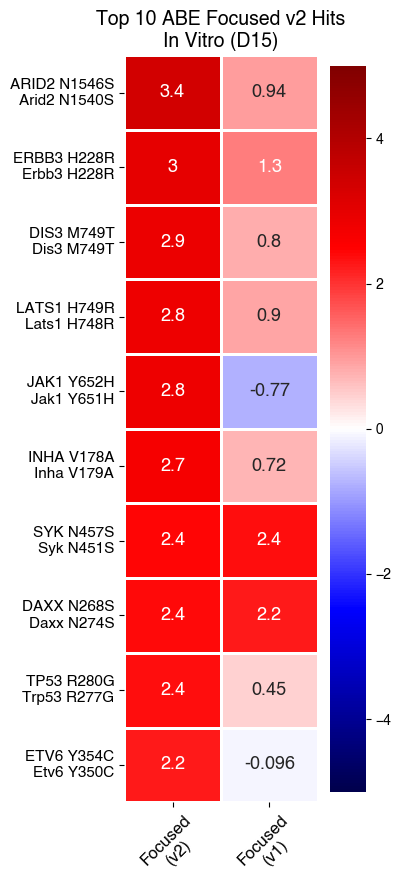

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


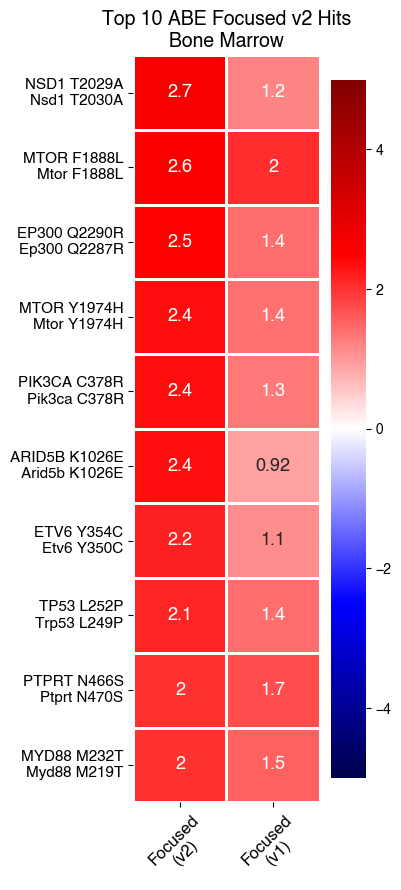

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


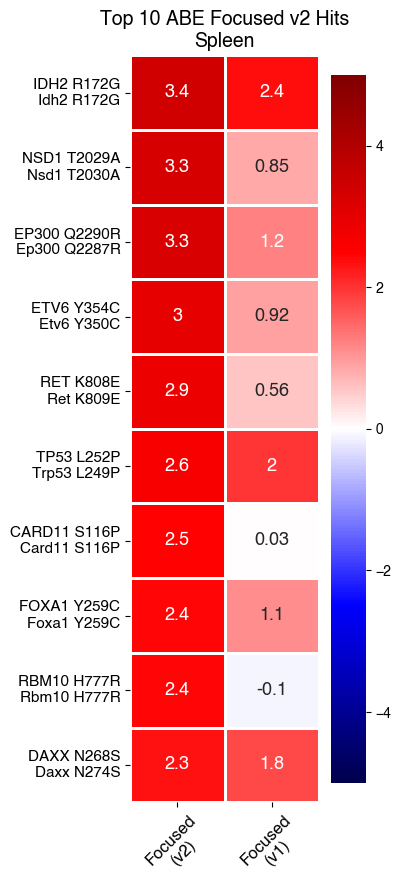

In [35]:
for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    fsr = ABE_FSR[ABE_FSR['classification'] == 'targeting guide'].copy()
    if sensor_col in fsr.columns:
        fsr = fsr[fsr[sensor_col] >= min_sensor_focused]
    fsr = fsr[fsr['Input_median'] >= 2]
    fsr = fsr[
        (fsr[edit_col]  >= min_edit) &
        (fsr[fdr_col]   <= FDR_cutoff) &
        (fsr[lfc_col].abs() >= LFC_cutoff)
    ].copy()
    fsr = fsr.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = fsr.iloc[:10].copy()

    t0 = ABE_T0[['gRNA_id', z_col]].rename(columns={z_col: 'z_t0'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], t0, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_fsr'})

    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_fsr', 'z_t0']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['Focused\n(v2)', 'Focused\n(v1)'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE Focused v2 Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figures/ext-14/14d_top10_v2_{cond}.pdf', bbox_inches='tight')
    plt.show()


## 14e

Volcano plots showing guide-level median LFC versus -log10(FDR) for the focused ABE screen with v1 baseline (top row) and v2 baseline (bottom row), across three tissue contexts (Day 15 In Vitro, Spleen, and Bone Marrow). Blue dots, targeting guides; red dots, control guides. Dashed horizontal line, FDR = 0.1; dotted vertical lines, |LFC| = 1.0.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


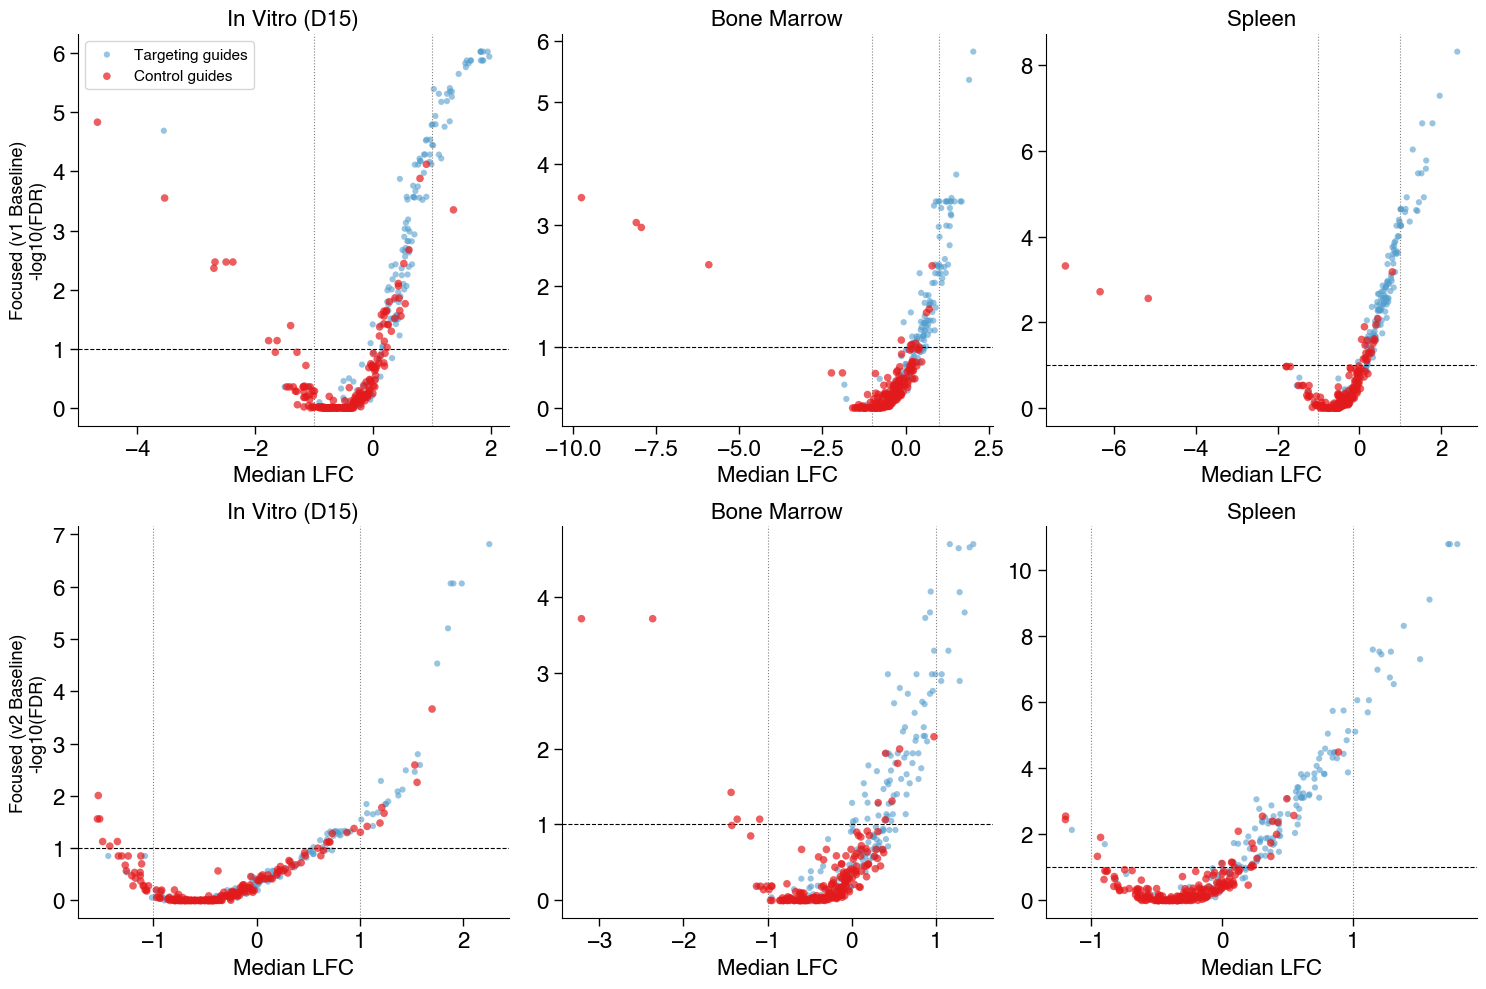

In [36]:
min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_focused = 100

conditions  = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro (D15)', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

screens = [
    (dfs['ABE_EPO_T0'],     min_sensor_focused, 'Focused (v1 Baseline)'),
    (dfs['ABE_EPO_T0_FSR'], min_sensor_focused, 'Focused (v2 Baseline)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (df, min_sensor, screen_label) in enumerate(screens):
    input_ok = df['Input_median'] >= 2

    for k, cond in enumerate(conditions):
        lfc_col   = f'LFC_median_{cond}'
        fdr_col   = f'FDR_{cond}_fishers'
        reads_col = f'sensor_reads_{cond}'
        edit_col  = f'target_base_edit_perc_{cond}'
        ax = axes[row, k]

        guide_ok = input_ok & (df[reads_col] >= min_sensor) & (df[edit_col] >= min_edit)

        targ = df[(df['classification'] == 'targeting guide') & guide_ok].copy()
        ntc  = df[df['classification'] == 'non-targeting control'].copy()
        stc  = df[df['classification'] == 'safe-targeting control'].copy()

        if len(targ):
            neg_log_fdr = -np.log10(targ[fdr_col].clip(lower=1e-300))
            ax.scatter(targ[lfc_col], neg_log_fdr,
                       c=blues[3], s=20, alpha=0.6,
                       linewidths=0, edgecolors='none',
                       label='Targeting guides')

        ctrl_plotted = False
        for ctrl_df in [ntc, stc]:
            if len(ctrl_df):
                yvals = -np.log10(ctrl_df[fdr_col].clip(lower=1e-300))
                ax.scatter(ctrl_df[lfc_col], yvals,
                           c='#e41a1c', s=30, alpha=0.7,
                           linewidths=0, edgecolors='none', zorder=3,
                           label='Control guides' if not ctrl_plotted else '_nolegend_')
                ctrl_plotted = True

        ax.axhline(-np.log10(FDR_cutoff), color='black', linestyle='--', linewidth=0.8)
        ax.axvline( LFC_cutoff, color='grey', linestyle=':', linewidth=0.8)
        ax.axvline(-LFC_cutoff, color='grey', linestyle=':', linewidth=0.8)

        ax.set_title(cond_labels[cond], fontsize=16)
        ax.set_xlabel('Median LFC', fontsize=16)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=16, direction='out', length=6, width=1)
        if k == 0:
            ax.set_ylabel(f'{screen_label}\n-log10(FDR)', fontsize=13)
        if row == 0 and k == 0:
            ax.legend(fontsize=11, loc='upper left')

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-14/14e_volcano.pdf', bbox_inches='tight')
plt.show()


## 14f

Histograms showing the distribution of median LFC values for targeting guides (colored by tissue) and control guides (grey) in the focused ABE screen with v1 baseline (top row) and v2 baseline (bottom row), across three tissue contexts (Day 15 In Vitro, Spleen, and Bone Marrow). Dynamic range (DR), defined as the difference between the 95th and 5th percentiles of targeting guide LFC values, is annotated in each panel.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


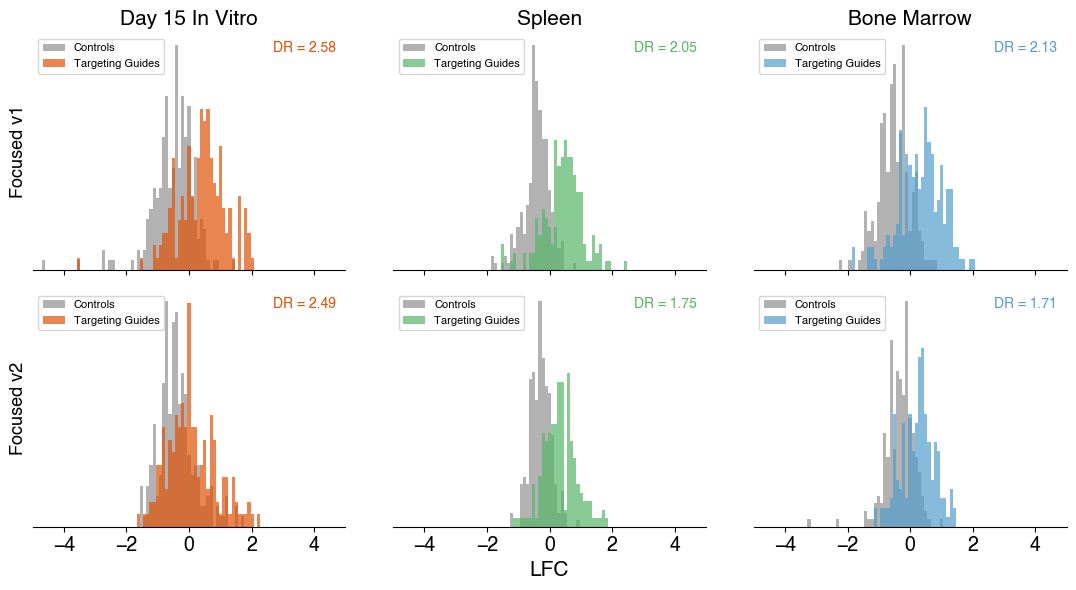

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=False)

conditions    = ['d15', 'spleen', 'bm']
name_dict     = {'d15': 'Day 15 In Vitro', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}
tissue_colors = {'d15': yellows[4], 'spleen': greens[3], 'bm': blues[3]}

ABE_T0  = dfs['ABE_EPO_T0']
ABE_FSR = dfs['ABE_EPO_T0_FSR']

bins = np.linspace(-5, 5, 100)

for idx, cond in enumerate(conditions):
    lfc_col = f'LFC_median_{cond}'
    color   = tissue_colors[cond]

    for row, (df, screen_label) in enumerate([
        (ABE_T0,  'Focused v1'),
        (ABE_FSR, 'Focused v2'),
    ]):
        ax = axes[row][idx]

        if lfc_col not in df.columns:
            ax.set_visible(False)
            continue

        targ = df[df['classification'] == 'targeting guide'][lfc_col].dropna()
        ctrl = df[df['classification'].isin(['non-targeting control', 'safe-targeting control'])][lfc_col].dropna()

        ax.hist(ctrl, density=True, bins=bins, alpha=0.6, color='grey',  label='Controls')
        ax.hist(targ, density=True, bins=bins, alpha=0.7, color=color,   label='Targeting Guides')

        dr = np.percentile(targ, 95) - np.percentile(targ, 5)
        ax.text(0.97, 0.97, f'DR = {dr:.2f}',
                transform=ax.transAxes, fontsize=10,
                ha='right', va='top', color=color)

        if row == 0:
            ax.set_title(name_dict[cond], fontsize=15)
        ax.set_xlim(-5, 5)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.set_yticks([])
        ax.tick_params(axis='x', which='major', labelsize=14)
        ax.legend(fontsize=8, loc='upper left', frameon=True)

axes[0][0].set_ylabel('Focused v1', fontsize=13)
axes[1][0].set_ylabel('Focused v2', fontsize=13)
axes[1][1].set_xlabel('LFC', fontsize=15)

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-14/14f_hist.pdf', bbox_inches='tight', dpi=300)
plt.show()
